In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.linalg import cholesky, solve_triangular

# Zadanie 1 – Preconditioning

Funkcja: $f(x,y) = \frac{1}{2}x^2 + \frac{9}{2}y^2$

Hesjan: $\nabla^2 f = \begin{bmatrix}1 & 0\\ 0 & 9\end{bmatrix}$

In [2]:
def f1(xy):
    """Funkcja celu: f(x,y) = 0.5*x^2 + 4.5*y^2"""
    x, y = xy
    return 0.5 * x**2 + 4.5 * y**2

def grad_f1(xy):
    """Gradient funkcji f1."""
    x, y = xy
    return np.array([x, 9.0 * y])

def optimal_step_f1(xy):
    """
    Optymalny krok alfa_k dla gradientu prostego (exact line search).
    alfa_k = ||grad||^2 / (grad^T * H * grad)
    gdzie H = [[1,0],[0,9]] to Hesjan f1.
    """
    g = grad_f1(xy)
    H = np.diag([1.0, 9.0])
    return (g @ g) / (g @ H @ g)

def gradient_descent_f1(xy0, tol=1e-10, max_iter=1000):
    """
    Gradient prosty z optymalnym krokiem alfa_k dla funkcji f1.
    Zwraca historie kolejnych punktow.
    """
    xy = np.array(xy0, dtype=float)
    history = [xy.copy()]

    for _ in range(max_iter):
        g = grad_f1(xy)
        if np.linalg.norm(g) < tol:
            break
        alpha = optimal_step_f1(xy)
        xy = xy - alpha * g
        history.append(xy.copy())

    return np.array(history)

# Punkt startowy
xy0 = np.array([9.0, 1.0])
history_1a = gradient_descent_f1(xy0)

print(f"Liczba iteracji: {len(history_1a) - 1}")
print(f"Minimum znalezione: x={history_1a[-1,0]:.6f}, y={history_1a[-1,1]:.6f}")
print(f"f(minimum) = {f1(history_1a[-1]):.2e}")

Liczba iteracji: 115
Minimum znalezione: x=0.000000, y=-0.000000
f(minimum) = 2.31e-21


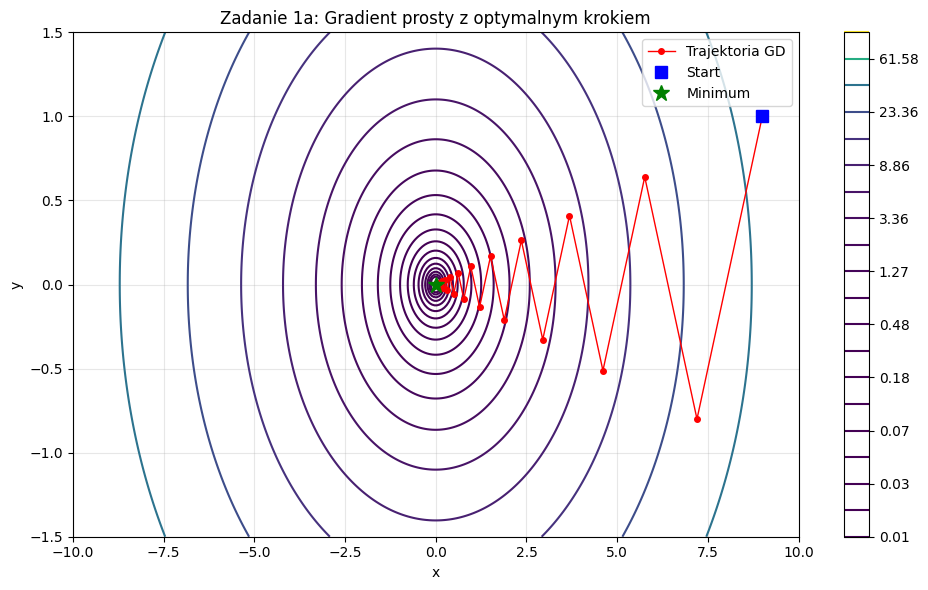

In [3]:
# Wykres konturowy z trajektoria algorytmu
x_grid = np.linspace(-10, 10, 300)
y_grid = np.linspace(-1.5, 1.5, 300)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid)
Z_grid = 0.5 * X_grid**2 + 4.5 * Y_grid**2

fig, ax = plt.subplots(figsize=(10, 6))
levels = np.logspace(-2, 2, 20)
cs = ax.contour(X_grid, Y_grid, Z_grid, levels=levels, cmap='viridis')
plt.colorbar(cs, ax=ax)

ax.plot(history_1a[:, 0], history_1a[:, 1], 'ro-', markersize=4, linewidth=1, label='Trajektoria GD')
ax.plot(*xy0, 'bs', markersize=8, label='Start')
ax.plot(0, 0, 'g*', markersize=12, label='Minimum')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Zadanie 1a: Gradient prosty z optymalnym krokiem')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [4]:
# 1b – wspolczynnik uwarunkowania Hessiana
H = np.diag([1.0, 9.0])
eigenvalues = np.linalg.eigvalsh(H)
cond_number = eigenvalues.max() / eigenvalues.min()

print(f"Wartosci wlasne Hessiana: {eigenvalues}")
print(f"Wspolczynnik uwarunkowania kappa = lambda_max / lambda_min = {cond_number:.2f}")
print(f"Zbieznosc gradientu prostego: ((kappa-1)/(kappa+1))^2 = {((cond_number-1)/(cond_number+1))**2:.4f} na krok")

Wartosci wlasne Hessiana: [1. 9.]
Wspolczynnik uwarunkowania kappa = lambda_max / lambda_min = 9.00
Zbieznosc gradientu prostego: ((kappa-1)/(kappa+1))^2 = 0.6400 na krok


In [5]:
# 1c – macierz L: H = L L^T  (dekompozycja Choleskiego)
# scipy cholesky zwraca U (gornotrojkatna), wiec L = U^T
U = cholesky(H)
L = U.T

print("Hesjan H ="); print(H)
print("\nMacierz L (dolnotrojkatna) ="); print(L)
print("\nSprawdzenie L @ L.T ="); print(L @ L.T)

Hesjan H =
[[1. 0.]
 [0. 9.]]

Macierz L (dolnotrojkatna) =
[[1. 0.]
 [0. 3.]]

Sprawdzenie L @ L.T =
[[1. 0.]
 [0. 9.]]


Liczba iteracji (po preconditioningu): 1
Minimum: x=0.000000, y=0.000000


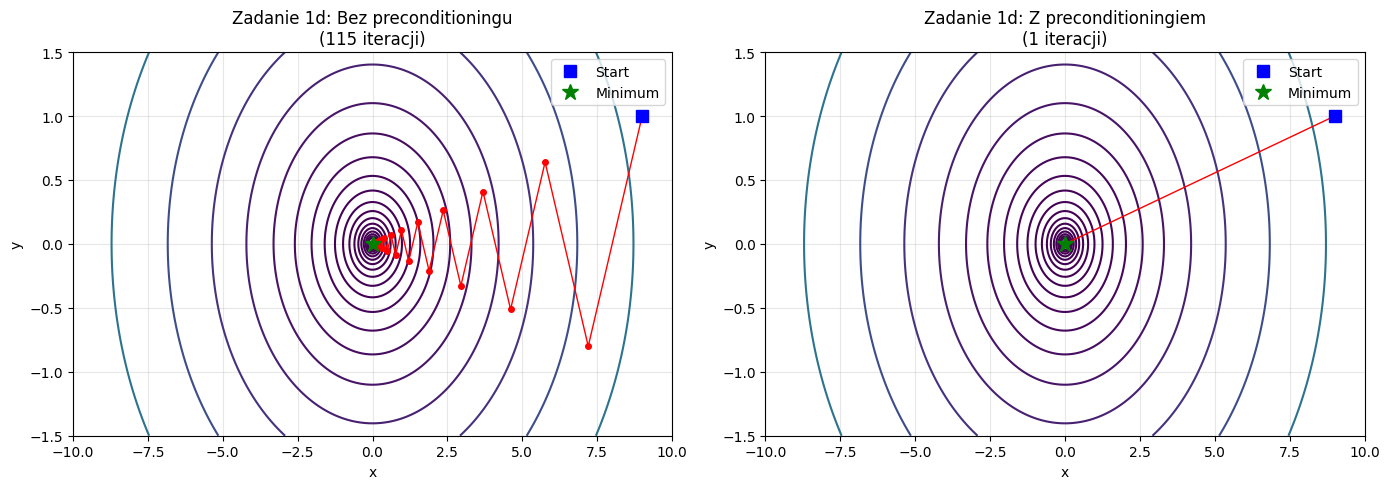

In [6]:
# 1d – preconditioning: minimalizacja g(x',y') = f(L^{-T} [x',y']^T)

L_inv_T = np.linalg.inv(L.T)   # L^{-T}

def g_precond(xp_yp):
    """g(x',y') = f(L^{-T} [x',y'])"""
    xy = L_inv_T @ np.array(xp_yp)
    return f1(xy)

def grad_g_precond(xp_yp):
    """
    grad_g = L^{-1} * grad_f(L^{-T} x')
    Hesjan g = L^{-1} H L^{-T} = I -> wspolczynnik uwarunkowania = 1
    """
    xy = L_inv_T @ np.array(xp_yp)
    gf = grad_f1(xy)
    return np.linalg.inv(L) @ gf

def gradient_descent_precond(xp_yp0, tol=1e-10, max_iter=1000):
    """Gradient prosty dla funkcji g (po preconditioningu)."""
    xp_yp = np.array(xp_yp0, dtype=float)
    history = [xp_yp.copy()]
    H_precond = np.eye(2)   # Hesjan g = I, wiec wspolczynnik = 1

    for _ in range(max_iter):
        g = grad_g_precond(xp_yp)
        if np.linalg.norm(g) < tol:
            break
        # Optymalny krok: alfa = ||g||^2 / (g^T I g) = 1
        alpha = 1.0
        xp_yp = xp_yp - alpha * g
        history.append(xp_yp.copy())

    return np.array(history)

# Punkt startowy w przestrzeni x'
xp0 = L @ xy0
history_precond = gradient_descent_precond(xp0)

# Przelicz z powrotem na (x, y)
history_xy = np.array([L_inv_T @ h for h in history_precond])
print(f"Liczba iteracji (po preconditioningu): {len(history_precond) - 1}")
print(f"Minimum: x={history_xy[-1,0]:.6f}, y={history_xy[-1,1]:.6f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, hist, title in zip(axes,
    [history_1a, history_xy],
    ['Bez preconditioningu', 'Z preconditioningiem']):
    cs = ax.contour(X_grid, Y_grid, Z_grid, levels=levels, cmap='viridis')
    ax.plot(hist[:,0], hist[:,1], 'ro-', markersize=4, linewidth=1)
    ax.plot(*xy0, 'bs', markersize=8, label='Start')
    ax.plot(0, 0, 'g*', markersize=12, label='Minimum')
    ax.set_title(f'Zadanie 1d: {title}\n({len(hist)-1} iteracji)')
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Zadanie 2 – Wiszący łańcuch

Minimalizujemy energię potencjalną łańcucha n+1 mas połączonych sprężynami:

$$V = \frac{k}{2}\sum_{i=0}^{n-1}\left(\sqrt{(x^{(i)}-x^{(i+1)})^2+(y^{(i)}-y^{(i+1)})^2}-L\right)^2 + g\sum_{i=0}^{n}m\,y^{(i)}$$

Warunki brzegowe: $(x^{(0)},y^{(0)})=(0,0)$, $(x^{(n)},y^{(n)})=(3,1)$

In [7]:
# Parametry lancucha
N  = 40          # liczba odcinkow (n+1 = 41 mas)
L  = 1/10        # dlugosc spoczynkowa sprezyny [m]
m  = 1/10        # masa kazdego punktu [kg]
k  = 70.0        # wspolczynnik sprezystosci [N/m]
g  = 9.81        # przyspieszenie grawitacyjne [m/s^2]

# Warunki brzegowe
x0_fix, y0_fix = 0.0, 0.0    # pierwszy punkt
xn_fix, yn_fix = 3.0, 1.0    # ostatni punkt

def unpack(z):
    """Zamienia wektor z [x_1,...,x_{n-1}, y_1,...,y_{n-1}] na tablice x i y (z warunkami brzegowymi)."""
    x_inner = z[:N-1]
    y_inner = z[N-1:]
    x = np.concatenate([[x0_fix], x_inner, [xn_fix]])
    y = np.concatenate([[y0_fix], y_inner, [yn_fix]])
    return x, y

def potential_energy(z):
    """Calkowita energia potencjalna lancucha."""
    x, y = unpack(z)
    # Energia sprezyn
    dx = np.diff(x)
    dy = np.diff(y)
    lengths = np.sqrt(dx**2 + dy**2)
    V_spring = 0.5 * k * np.sum((lengths - L)**2)
    # Energia grawitacji
    V_grav = g * m * np.sum(y)
    return V_spring + V_grav

def grad_potential(z):
    """
    Gradient energii potencjalnej wzgledem wspolrzednych wewnetrznych
    [x_1,...,x_{n-1}, y_1,...,y_{n-1}].
    """
    x, y = unpack(z)
    dx = np.diff(x)
    dy = np.diff(y)
    lengths = np.sqrt(dx**2 + dy**2)
    # Sila sprezyny i: F = k*(l_i - L) * (kierunek)
    stretch = k * (lengths - L) / lengths   # k*(l-L)/l

    grad_x = np.zeros(N+1)
    grad_y = np.zeros(N+1)

    for i in range(N):
        # Wplyw sprezyny i na masy i i i+1
        grad_x[i]   += stretch[i] * dx[i]
        grad_x[i+1] -= stretch[i] * dx[i]
        grad_y[i]   += stretch[i] * dy[i]
        grad_y[i+1] -= stretch[i] * dy[i]

    # Grawitacja
    grad_y += g * m

    # Zwracamy tylko wspolrzedne wewnetrzne (nie brzegowe)
    return np.concatenate([grad_x[1:N], grad_y[1:N]])

# Inicjalizacja: linia prosta miedzy punktami brzegowymi
z0 = np.concatenate([
    np.linspace(x0_fix, xn_fix, N+1)[1:N],   # x wewnetrzne
    np.linspace(y0_fix, yn_fix, N+1)[1:N]    # y wewnetrzne
])

print(f"Liczba stopni swobody: {len(z0)}")
print(f"Energia poczatkowa: {potential_energy(z0):.4f} J")

Liczba stopni swobody: 78
Energia poczatkowa: 20.7246 J


In [8]:
def gradient_descent_fixed(grad_fn, energy_fn, z0, alpha, max_iter=5000, tol=1e-6,
                            clip=None):
    """Gradient prosty ze stalym wspolczynnikiem uczenia alpha.
    clip – maksymalna norma gradientu (gradient clipping).
    """
    z = z0.copy()
    energies = [energy_fn(z)]

    for i in range(max_iter):
        g = grad_fn(z)
        g_norm = np.linalg.norm(g)
        if g_norm < tol:
            print(f"  Zbieznosc po {i} iteracjach")
            break
        if clip is not None and g_norm > clip:
            g = g * clip / g_norm
        z = z - alpha * g
        energies.append(energy_fn(z))

    return z, np.array(energies)

# Bezpieczny krok wyznaczony analitycznie: L_smooth = k*(n+1) = 70*41 ~ 2870
# alpha < 2/L_smooth ~ 7e-4; uzywamy 1e-4 z gradient clipping dla bezpieczenstwa
alpha_fixed = 5e-4
z_fixed, E_fixed = gradient_descent_fixed(
    grad_potential, potential_energy, z0,
    alpha=alpha_fixed, clip=50.0, max_iter=5000
)
print(f"(a) Staly krok alpha={alpha_fixed}: E_final = {E_fixed[-1]:.4f} J, iteracji = {len(E_fixed)}")

(a) Staly krok alpha=0.0005: E_final = 1881127.0167 J, iteracji = 5001


In [9]:
def gradient_descent_decay(grad_fn, energy_fn, z0, alpha0=1e-3, decay=0.7,
                            decay_every=200, max_iter=5000, tol=1e-6, clip=50.0):
    """Gradient prosty z wykladniczo malejacym krokiem."""
    z = z0.copy()
    energies = [energy_fn(z)]
    alpha = alpha0

    for i in range(max_iter):
        if i > 0 and i % decay_every == 0:
            alpha *= decay
        g = grad_fn(z)
        g_norm = np.linalg.norm(g)
        if g_norm < tol:
            print(f"  Zbieznosc po {i} iteracjach")
            break
        if clip is not None and g_norm > clip:
            g = g * clip / g_norm
        z = z - alpha * g
        energies.append(energy_fn(z))

    return z, np.array(energies)

z_decay, E_decay = gradient_descent_decay(grad_potential, potential_energy, z0)
print(f"(b) Malejacy krok: E_final = {E_decay[-1]:.4f} J, iteracji = {len(E_decay)}")

(b) Malejacy krok: E_final = 119893.7925 J, iteracji = 5001


In [10]:
def backtracking_line_search(fn, grad_fn, z, d, alpha0=1.0, rho=0.5, c=1e-4):
    """Backtracking line search (warunek Armijo)."""
    alpha = alpha0
    f0 = fn(z)
    g0 = grad_fn(z)
    for _ in range(50):
        if fn(z - alpha * d) <= f0 - c * alpha * (g0 @ d):
            break
        alpha *= rho
    return alpha

def gradient_descent_linesearch(grad_fn, energy_fn, z0, max_iter=2000, tol=1e-6):
    """Gradient prosty z przeszukiwaniem liniowym (backtracking Armijo)."""
    z = z0.copy()
    energies = [energy_fn(z)]

    for i in range(max_iter):
        g = grad_fn(z)
        if np.linalg.norm(g) < tol:
            print(f"  Zbieznosc po {i} iteracjach")
            break
        alpha = backtracking_line_search(energy_fn, grad_fn, z, g)
        z = z - alpha * g
        energies.append(energy_fn(z))

    return z, np.array(energies)

z_ls, E_ls = gradient_descent_linesearch(grad_potential, potential_energy, z0)
print(f"(c) Line search: E_final = {E_ls[-1]:.4f} J, iteracji = {len(E_ls)}")

(c) Line search: E_final = 12.9596 J, iteracji = 2001


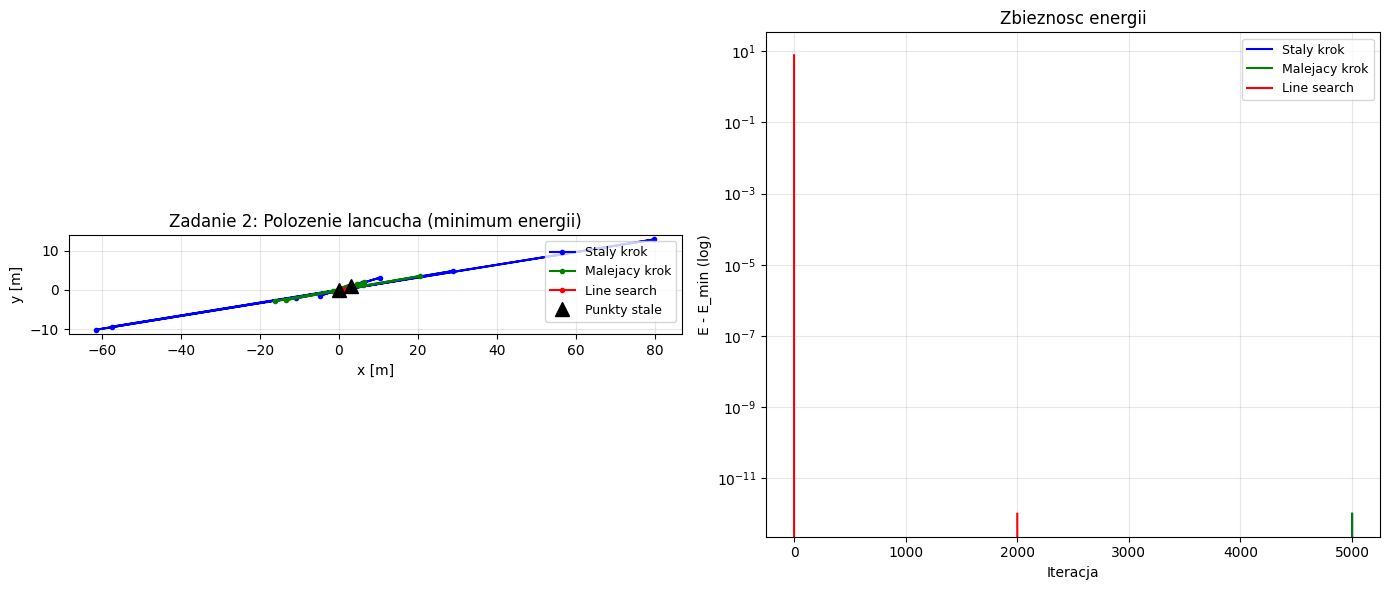


Porownanie metod:
Metoda                E_final [J]   Iteracji
--------------------------------------------
Staly krok           1881127.016685       5000
Malejacy krok        119893.792460       5000
Line search             12.959618       2000


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Wykres lancucha
ax = axes[0]
for z_, lbl, col in [(z_fixed, 'Staly krok', 'b'),
                     (z_decay, 'Malejacy krok', 'g'),
                     (z_ls,   'Line search', 'r')]:
    xc, yc = unpack(z_)
    ax.plot(xc, yc, '-o', color=col, markersize=3, linewidth=1.5, label=lbl)

ax.plot([x0_fix, xn_fix], [y0_fix, yn_fix], 'k^', markersize=10, label='Punkty stale')
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.set_title('Zadanie 2: Polozenie lancucha (minimum energii)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

# Wykres zbieznosci energii
ax2 = axes[1]
ax2.semilogy(E_fixed - E_fixed[-1] + 1e-12, 'b', label=f'Staly krok')
ax2.semilogy(E_decay - E_decay[-1] + 1e-12, 'g', label=f'Malejacy krok')
ax2.semilogy(E_ls    - E_ls[-1]    + 1e-12, 'r', label=f'Line search')
ax2.set_xlabel('Iteracja')
ax2.set_ylabel('E - E_min (log)')
ax2.set_title('Zbieznosc energii')
ax2.legend(fontsize=9)
ax2.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nPorownanie metod:")
print(f"{'Metoda':<20} {'E_final [J]':>12} {'Iteracji':>10}")
print("-" * 44)
for lbl, E in [('Staly krok', E_fixed), ('Malejacy krok', E_decay), ('Line search', E_ls)]:
    print(f"{lbl:<20} {E[-1]:>12.6f} {len(E)-1:>10}")

# Zadanie 3 – Predykcja roku wydania (gradient descent)

Wczytujemy dane z Lab 2 (YearPredictionMSD.txt) i porownujemy:
- **Metoda najmniejszych kwadratow** (rozwiazanie dokladne: $\\theta = (A^T A)^{-1} A^T y$)
- **Gradient descent** ze stala uczaca $\\alpha = 2 / (\\lambda_{\\min} + \\lambda_{\\max})$

In [12]:
import time

# Wczytanie danych (pierwsze 51 kolumn)
print("Wczytywanie danych...")
t0 = time.time()
df = pd.read_csv('../lab2/YearPredictionMSD.txt', header=None)
print(f"  Wczytano {len(df)} rekordow w {time.time()-t0:.1f}s")

# Podzial train/test (zgodnie z lab2)
train = df.iloc[:463715]
test  = df.drop(train.index)

y_train = train[0].values.astype(np.float64)
X_train = train.drop(0, axis=1).values.astype(np.float64)
y_test  = test[0].values.astype(np.float64)
X_test  = test.drop(0, axis=1).values.astype(np.float64)

# Normalizacja cech X (min-max do [0, 1])
X_min = X_train.min(axis=0)
X_max = X_train.max(axis=0)
eps   = 1e-8
X_train_sc = (X_train - X_min) / (X_max - X_min + eps)
X_test_sc  = (X_test  - X_min) / (X_max - X_min + eps)

# Dodajemy kolumne jedynek (bias)
ones_tr = np.ones((X_train_sc.shape[0], 1))
ones_te = np.ones((X_test_sc.shape[0],  1))
A_train = np.hstack([ones_tr, X_train_sc])
A_test  = np.hstack([ones_te, X_test_sc])

# Normalizacja zmiennej celu y (lata) do przedzialu [0, 1]
y_min_tr, y_max_tr = y_train.min(), y_train.max()
y_train_sc = (y_train - y_min_tr) / (y_max_tr - y_min_tr)
y_test_sc  = (y_test  - y_min_tr) / (y_max_tr - y_min_tr)

print(f"A_train: {A_train.shape},  A_test: {A_test.shape}")
print(f"y_train_sc: min={y_train_sc.min():.2f}, max={y_train_sc.max():.2f}")

Wczytywanie danych...


  Wczytano 515345 rekordow w 3.0s


A_train: (463715, 91),  A_test: (51630, 91)
y_train_sc: min=0.00, max=1.00


In [13]:
# 3a – Metoda najmniejszych kwadratow (rozwiazanie na danych znormalizowanych)
t0 = time.time()
# LSTSQ rozwiazuje układ na znormalizowanym wektorze celu y_train_sc
theta_lstsq = np.linalg.lstsq(A_train, y_train_sc, rcond=None)[0]
t_lstsq = time.time() - t0

# Predykcja na znormalizowanym zbiorze testowym
y_pred_lstsq_sc = A_test @ theta_lstsq

# Powrot do oryginalnej skali i obliczenie RMSE (z oryginalnym y_test)
y_pred_lstsq = y_pred_lstsq_sc * (y_max_tr - y_min_tr) + y_min_tr
rmse_lstsq   = np.sqrt(np.mean((y_pred_lstsq - y_test)**2))

print(f"Metoda najmniejszych kwadratow (LS):")
print(f"  Czas: {t_lstsq:.2f} s")
print(f"  RMSE (test): {rmse_lstsq:.4f} lat")

Metoda najmniejszych kwadratow (LS):
  Czas: 1.10 s
  RMSE (test): 9.5102 lat


In [14]:
# 3b - Gradient descent na danych znormalizowanych
# Zgodnie z poleceniem stala uczaca wynosi alpha = 2 / (lambda_min + lambda_max) macierzy A^T A

print("Obliczanie dokladnych wartosci wlasnych macierzy A^T A...")
# Macierz A_train ma wymiary (463715, 91), wiec A^T A ma 91x91 (bardzo szybkie obliczenia)
ATA = A_train.T @ A_train
lambdas = np.linalg.eigvalsh(ATA)
lambda_min = lambdas.min()
lambda_max = lambdas.max()

alpha_gd = 2.0 / (lambda_min + lambda_max)

print(f"  lambda_min(A^T A) = {lambda_min:.4e}")
print(f"  lambda_max(A^T A) = {lambda_max:.4e}")
print(f"  Stala uczaca alpha = {alpha_gd:.4e}")

def mse_sc(theta):
    """MSE na znormalizowanych danych."""
    r = A_train @ theta - y_train_sc
    return float(np.mean(r**2))

def grad_f(theta):
    """Gradient dla funkcji kosztu f = 1/2 ||A*theta - y||^2, ktorej hesjan to A^T A.
       Zatem grad = A^T (A*theta - y).
    """
    r = A_train @ theta - y_train_sc
    return A_train.T @ r

theta_gd = np.zeros(A_train.shape[1])
n_iter_gd = 500
log_every = 50
iters_log = list(range(0, n_iter_gd + 1, log_every))
rmse_log  = []

print("\nTrening gradient descent...")
t0 = time.time()
for i in range(n_iter_gd + 1):
    if i % log_every == 0:
        # Skalujemy blad treningowy od razu do lat dla wykresu
        rmse_cur_lat = np.sqrt(mse_sc(theta_gd)) * (y_max_tr - y_min_tr)
        rmse_log.append(rmse_cur_lat)
        print(f"  Iter {i:4d}: RMSE_train = {rmse_cur_lat:.4f} lat")
    if i < n_iter_gd:
        theta_gd = theta_gd - alpha_gd * grad_f(theta_gd)
t_gd = time.time() - t0

# Predykcja na znormalizowanym zbiorze testowym i powrot do skali lat
y_pred_gd_sc = A_test @ theta_gd
y_pred_gd    = y_pred_gd_sc * (y_max_tr - y_min_tr) + y_min_tr
rmse_gd      = np.sqrt(np.mean((y_pred_gd - y_test)**2))

print(f"\nGradient descent ({n_iter_gd} iteracji):")
print(f"  Czas: {t_gd:.2f} s")
print(f"  RMSE (test): {rmse_gd:.4f} lat")

Obliczanie dokladnych wartosci wlasnych macierzy A^T A...
  lambda_min(A^T A) = 4.5766e+00
  lambda_max(A^T A) = 9.8235e+06
  Stala uczaca alpha = 2.0359e-07

Trening gradient descent...
  Iter    0: RMSE_train = 77.1655 lat


  Iter   50: RMSE_train = 77.1563 lat


  Iter  100: RMSE_train = 77.1474 lat


  Iter  150: RMSE_train = 77.1389 lat


  Iter  200: RMSE_train = 77.1308 lat


...

  Iter  300: RMSE_train = 77.1153 lat


  Iter  350: RMSE_train = 77.1079 lat


  Iter  400: RMSE_train = 77.1007 lat


  Iter  450: RMSE_train = 77.0936 lat


  Iter  500: RMSE_train = 77.0868 lat

Gradient descent (500 iteracji):
  Czas: 7.29 s
  RMSE (test): 77.1863 lat


Metoda                          RMSE (test)   Czas [s]
-------------------------------------------------------
Najmniejsze kwadraty                 9.5102       1.10
Gradient descent (GD)               77.1863       7.29

Zlozonosc obliczeniowa:
  Najmniejsze kwadraty: O(n*d^2 + d^3) ~ O(3.84e+09)
  Gradient descent:     O(n*d) = O(4.22e+07) na iteracje


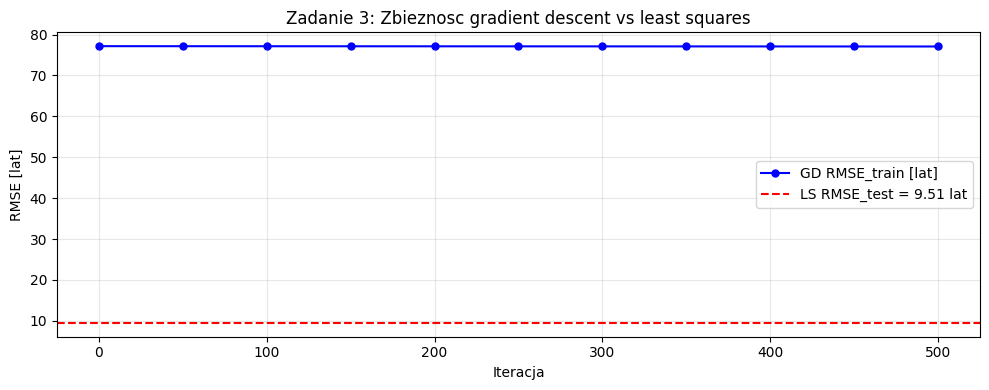

In [15]:
# Porownanie wynikow – obie metody na tych samych danych
header = "{:<30} {:>12} {:>10}".format("Metoda", "RMSE (test)", "Czas [s]")
row_ls = "{:<30} {:>12.4f} {:>10.2f}".format("Najmniejsze kwadraty", rmse_lstsq, t_lstsq)
row_gd = "{:<30} {:>12.4f} {:>10.2f}".format("Gradient descent (GD)", rmse_gd,   t_gd)
print("=" * 55)
print(header)
print("-" * 55)
print(row_ls)
print(row_gd)
print("=" * 55)
print()
n_tr, d_tr = A_train.shape
print("Zlozonosc obliczeniowa:")
print(f"  Najmniejsze kwadraty: O(n*d^2 + d^3) ~ O({n_tr*d_tr**2:.2e})")
print(f"  Gradient descent:     O(n*d) = O({n_tr*d_tr:.2e}) na iteracje")

# Wykres zbieznosci RMSE (ta sama skala: lata)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(iters_log, rmse_log, "b-o", markersize=5, label="GD RMSE_train [lat]")
ax.axhline(rmse_lstsq, color="r", linestyle="--", linewidth=1.5,
           label=f"LS RMSE_test = {rmse_lstsq:.2f} lat")
ax.set_xlabel("Iteracja")
ax.set_ylabel("RMSE [lat]")
ax.set_title("Zadanie 3: Zbieznosc gradient descent vs least squares")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()